### 11.DISTINCT
- DESCRIBE movies_genre;
- SELECT genre FROM movies;
- SELECT DISTINCT genre FROM movies_genre;

- SELECT DISTINCT first_name,last_name FROM directors ORDER BY first_name;

### 12.WHERE, comparison operators, NULL
#### list all movies with rankscore>9
- SELECT name,year,rankscore FROM movies WHERE rankscore>9 ;
- SELECT name,year,rankscore FROM movies WHERE rankscore>9 ORDER BY rankscore DESC LIMIT 20;

#### Condition's outputs: TRUE, FALSE, NULL
#### Comparison Operators: = , <> or != , < , <= , >, >= 
- SELECT * FROM movies_genres WHERE genre = 'Comedy';
- SELECT * FROM movies_genres WHERE genre <> 'Horror'; or SELECT * FROM movies_genres WHERE genre != 'Horror';

#### NULL => doesnot-exist/unknown/missing
#### "=" doesnot work with NULL, will give you an empty result-set.
- SELECT name,year,rankscore FROM movies WHERE rankscore = NULL;
- SELECT name,year,rankscore FROM movies WHERE rankscore IS NULL LIMIT 20;
- SELECT name,year,rankscore FROM movies WHERE rankscore IS NOT NULL LIMIT 20;


### 13.LOGICAL operators: AND, OR, NOT, ALL, ANY, BETWEEN, EXISTS, IN, LIKE, SOME
#### website search filters(ex: in amazon searching for t-shirt where material: cotton and brands: flying machine)
- SELECT name,year,rankscore FROM movies WHERE rankscore>9 AND year>2000;
- SELECT name,year,rankscore FROM movies WHERE NOT year<=2000 LIMIT 20;   (equivalent to year>2000)
- SELECT name,year,rankscore FROM movies WHERE rankscore>9 OR year>2007;

#### will discsuss about ANY and ALL when we discuss sub-queries

####  inclusive: year>=1999 AND year<=2000
- SELECT name,year,rankscore FROM movies WHERE year BETWEEN 1999 AND 2000;
- SELECT name,year,rankscore FROM movies WHERE year>=1999 AND year<=2000;

####  lowvalue <= highvalue else you will get an empty result set
- SELECT name,year,rankscore FROM movies WHERE year BETWEEN 2000 AND 1999;  #will not work

####  same as genre='Comedy' OR genre='Horror' OR genre='Drama'
- SELECT director_id, genre FROM directors_genres WHERE genre IN ('Comedy','Horror');

####  % => wildcard character to imply zero or more characters
- SELECT name,year,rankscore FROM movies WHERE name LIKE 'Tis%';    #starts with Tis

####  first name ending in 'es'
- SELECT first_name, last_name FROM actors WHERE first_name LIKE '%es';

####  first name contains 'es'
- SELECT first_name, last_name FROM actors WHERE first_name LIKE '%es%';

####  '_' implies exactly one character.
- SELECT first_name, last_name FROM actors WHERE first_name LIKE 'Agn_s';

####  If we want to match % or _, we should use the backslash as the escape character: \% and \_
- SELECT first_name, last_name FROM actors WHERE first_name LIKE 'L%' AND first_name NOT LIKE 'Li%';

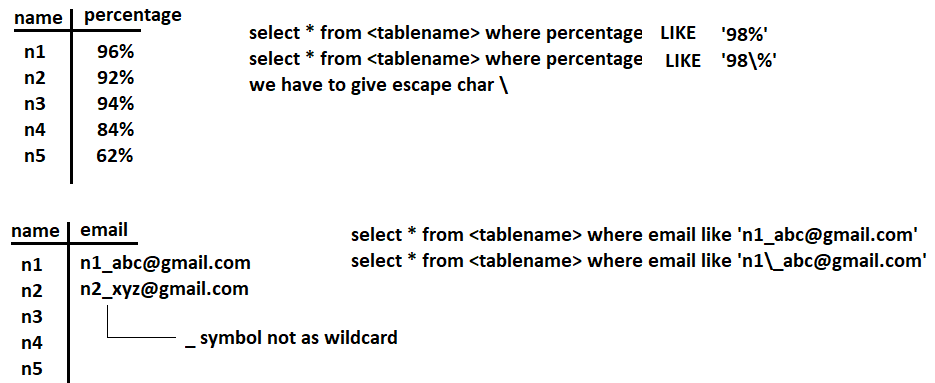

In [1]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql2.png")

### 14. Aggregate Functions: COUNT, MIN, MAX, AVG, SUM
#### Aggregate functions: Computes a single value on a set of rows and returns the aggreagate
- SELECT MIN(year) FROM movies;                        # min year 1888
- SELECT MAX(year) FROM movies;
- SELECT COUNT(*) FROM movies;                         # no. of rows in all columns 388269
- SELECT COUNT(*) FROM movies where year>2000;         # 46006
- SELECT COUNT(year) FROM movies;                      # no. of rows in year column 388269

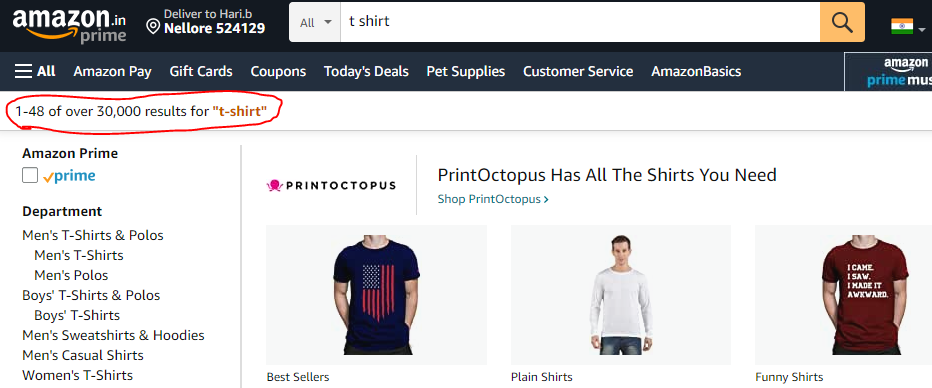

In [2]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql3.png")

###  15.GROUP-BY(mostly used by datascientist )
#### find number of movies released per year
- SELECT year, COUNT(year) FROM movies GROUP BY year;           # year and no. of movies in that year
- SELECT year, COUNT(year) FROM movies GROUP BY year ORDER BY year;  # sorted by year
- SELECT year, COUNT(year) year_count FROM movies GROUP BY year ORDER BY year_count; 
#### year_count is an alias.
#### often used with COUNT, MIN, MAX or SUM.
#### if grouping columns contain NULL values, all null values are grouped together.

### 16.HAVING
#### Print years which have >1000 movies in our DB [Data Scientist for Analysis]
#### specify a condition on groups using HAVING.
- SELECT year, COUNT(year) year_count FROM movies GROUP BY year HAVING year_count>1000;

#### Order of execution:
    - 1. GROUP BY to create groups
    - 2. apply the AGGREGATE FUNCTION
    - 3. Apply HAVING condition.

#### often used along with GROUP BY. Not Mandatory.
#### HAVING without GROUP BY is same as WHERE
- SELECT name, year  FROM movies HAVING year>2000;



#### HAVING vs WHERE
#### WHERE is applied on individual rows while HAVING is applied on groups.
#### HAVING is applied after grouping while WHERE is used before grouping.
SELECT year, COUNT(year) year_count FROM movies WHERE rankscore>9 GROUP BY year HAVING year_count>20;

### 17.Order of keywords(https://dev.mysql.com/doc/refman/8.0/en/select.html)

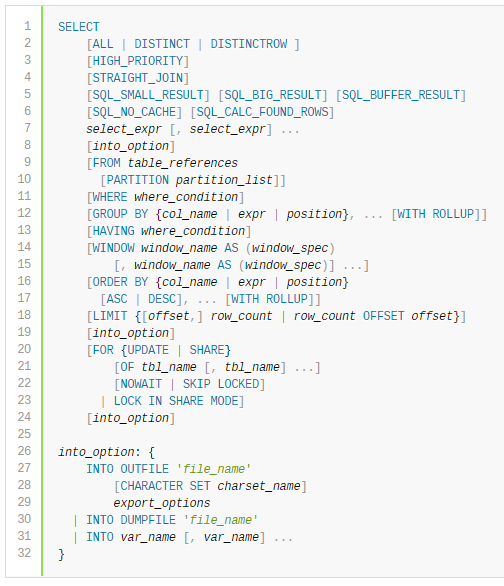

In [3]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql4.png")

### 18. Joins & Natural joins
#### combine data in multiple tables
#### For each movie, print name and the genres
#### table aliases: m and g
- SELECT m.name, g.genre from movies m  JOIN movies_genres g ON m.id=g.movie_id LIMIT 20;   #inner join



#### natural join: a join where we have the same column-names across two tables.
#### T1: C1, C2
#### T2: C1, C3, C4
- SELECT * FROM T1 JOIN T2;
- SELECT * FROM T1 JOIN T2 USING (C1);

#### returns C1,C2,C3,C4
#### no need to use the keyword "ON"

### 19. Inner join (default) vs left outer vs right outer vs full-outer join.

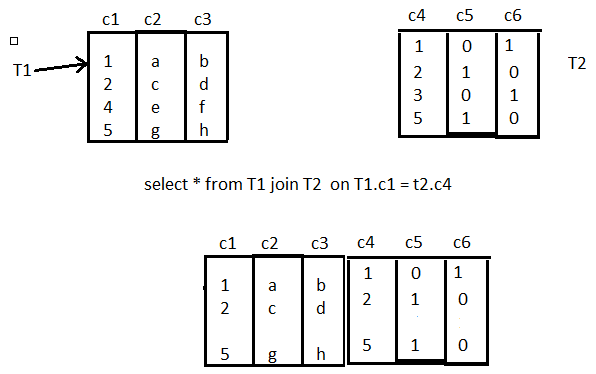

In [1]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql5.png")

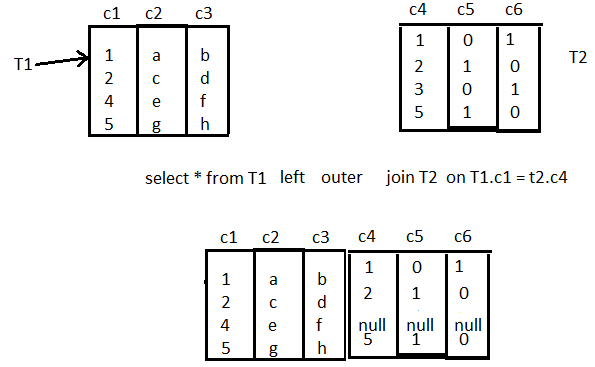

In [3]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql6.png")

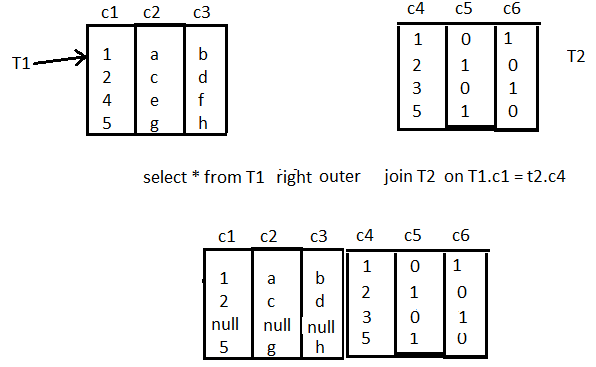

In [4]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql7.png")

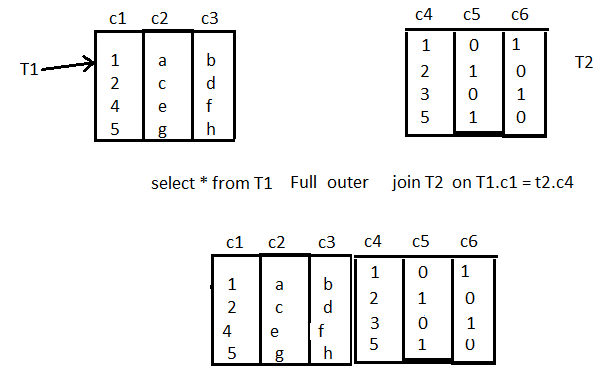

In [5]:
from PIL import Image
Image.open("E:/code/4.Databases/img/sql8.png")

#### T1: C1, C2, C3
- SELECT m.name, g.genre from movies m  LEFT JOIN movies_genres g ON m.id=g.movie_id LIMIT 20;

#### LEFT JOIN or LEFT OUTER JOIN
#### RIGHT JOIN or RIGHT OUTER JOIN
#### FULL JOIN or FULL OUTER JOIN
#### JOIN or INNER JOIN


#### NULL for missing counterpart rows.

#### 3-way joins and k-way joins
- SELECT a.first_name, a.last_name FROM actors a JOIN roles r ON a.id=r.actor_id JOIN movies m on m.id=r.movie_id AND m.name='Officer 444';

#### Practical note about joins: Joins can be expensive computationally when we have large tables.